# Formative Assignment: Advanced Linear Algebra (PCA)
This notebook will guide you through the implementation of Principal Component Analysis (PCA). Fill in the missing code and provide the required answers in the appropriate sections. You will work with a dataset that is Africanized .



1.   Make sure to display outputs for each code cell when submitting.
2.   Do not write all your code on one cell
3. Do not use any libraries aside from numpy





### Dataset
**African Economic Outlook (African Development Bank), 2018 snapshot**: 60 African countries x 9 economic indicators (real GDP growth, per-capita GDP growth, household consumption, gross capital formation, exports, imports, fiscal balance, current account balance, inflation).

- Contains genuine missing values (13 empty cells) -> imputed with column means.
- Contains a non-numeric column (`Country and Regions Name`) -> kept only as a row label, not used as a feature.
- Only `numpy` and `matplotlib` are used for the analysis (`csv` is Python's built-in file reader).


In [ ]:
# Load the raw CSV
import csv
import numpy as np

with open("/content/african-economic-outlook.csv", newline="", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    rows = list(reader)

print(f"Loaded {len(rows)} rows")
print("Columns:", reader.fieldnames)

Loaded 1732 rows
Columns: ['Country and Regions', 'Country and Regions Name', 'Country and Regions - RegionId', 'Indicators', 'Indicators Name', 'Scale', 'Units', '1980', '1981', '1982', '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020']


In [ ]:
# Reshape raw rows into a countries x indicators numeric table
wanted_indicators = [
    "Real GDP growth (annual %)",
    "Real per Capita GDP Growth Rate (annual %)",
    "Household final consumption expenditure  (% of GDP)",
    "Gross capital formation (% of GDP)",
    "Exports of goods and services (% of GDP)",
    "Imports of goods and services (% of GDP)",
    "Central government, Fiscal Balance (% of GDP)",
    "Current account balance (As % of GDP)",
    "Inflation, consumer prices (annual %)",
]
year = "2018"

data_dict = {}
for row in rows:
    country = row["Country and Regions Name"]
    indicator = row["Indicators Name"]
    if indicator in wanted_indicators and country != "Africa":
        val = row[year]
        data_dict.setdefault(country, {})[indicator] = float(val) if val else np.nan

countries = sorted(data_dict.keys())
X = np.full((len(countries), len(wanted_indicators)), np.nan)
for i, c in enumerate(countries):
    for j, ind in enumerate(wanted_indicators):
        X[i, j] = data_dict[c].get(ind, np.nan)

print("X shape:", X.shape)     # (60, 9)
print("Missing values:", np.isnan(X).sum())   # 13

X shape: (60, 9)
Missing values: 13


### Step 1: Load and Standardize the Data
Before applying PCA, we must standardize the dataset. Standardization ensures that all features have a mean of 0 and a standard deviation of 1, which is essential for PCA.
Fill in the code to standardize the dataset.

STRICTLY - Write code that implements standardization based on the image below

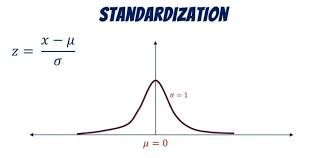


In [ ]:
# Step 1: Load and Standardize the data (use of numpy only allowed)

# Handle missing values: fill with each indicator's column mean
col_means = np.nanmean(X, axis=0)
missing_rows, missing_cols = np.where(np.isnan(X))
X[missing_rows, missing_cols] = np.take(col_means, missing_cols)

def standardize(data):
    mean = np.mean(data, axis=0)
    std = np.std(data, axis=0)
    return (data - mean) / std

standardized_data = standardize(X)
standardized_data[:5]  # Display the first few rows of standardized data

array([[-0.41744724, -0.15062802, -2.00228602,  2.61214041, -0.35776612,
        -0.42431675, -0.3304778 , -0.46023445, -0.23491367],
       [-1.59268985, -1.82833136, -1.34560824,  0.57179063,  0.21282797,
        -0.99721971,  0.49212823,  0.95841254,  0.86005018],
       [ 0.81541148,  0.63747693,  0.51727183,  0.43257287,  0.06733302,
         0.4757621 , -0.15493654, -0.73168763, -0.50250363],
       [ 0.17128047,  0.36332985, -1.57888762,  0.56211739,  0.57165105,
        -0.33962672,  1.09234932,  2.51763955, -0.37484232],
       [ 1.18990408,  0.94469365, -0.90155028,  0.24746498, -0.06948603,
        -0.0775268 , -0.20845946, -0.16326478, -0.5125311 ]])

In [ ]:
print("Missing values left:", np.isnan(X).sum())
print("Column means:", np.round(np.mean(standardized_data, axis=0), 3))
print("Column stds :", np.round(np.std(standardized_data, axis=0), 3))

Missing values left: 0
Column means: [ 0.  0. -0.  0.  0. -0.  0. -0.  0.]
Column stds : [1. 1. 1. 1. 1. 1. 1. 1. 1.]


### Step 3: Calculate the Covariance Matrix
The covariance matrix helps us understand how the features are related to each other. It is a key component in PCA.

In [5]:
# Step 3: Calculate the Covariance Matrix
cov_matrix = np.cov(standardized_data, rowvar=False)
cov_matrix

array([[ 1.01694915,  0.98458281,  0.19289897,  0.19479716, -0.29107342,
         0.02658822, -0.16169624, -0.07971586, -0.29698644],
       [ 0.98458281,  1.01694915,  0.17219003,  0.21127553, -0.17580733,
         0.15279658, -0.16809261, -0.07857405, -0.30726718],
       [ 0.19289897,  0.17219003,  1.01694915, -0.49977832, -0.33097859,
         0.11870733, -0.16281945, -0.40245489,  0.00575085],
       [ 0.19479716,  0.21127553, -0.49977832,  1.01694915,  0.07714369,
         0.24035606,  0.03554751, -0.22048804,  0.00249178],
       [-0.29107342, -0.17580733, -0.33097859,  0.07714369,  1.01694915,
         0.7353602 ,  0.13238411, -0.08012054, -0.13190727],
       [ 0.02658822,  0.15279658,  0.11870733,  0.24035606,  0.7353602 ,
         1.01694915, -0.0682731 , -0.52338501, -0.149768  ],
       [-0.16169624, -0.16809261, -0.16281945,  0.03554751,  0.13238411,
        -0.0682731 ,  1.01694915,  0.14796862,  0.11053576],
       [-0.07971586, -0.07857405, -0.40245489, -0.22048804, -0

In a paragraph that has a maximum if 5 Lines, Explain why we need to compute a covariance matrix, provide atleast 2 reasons

**Answer:** 
> We compute the covariance matrix because PCA looks for the directions in which the data varies most, and the covariance matrix captures exactly how the features vary and move together. First, it shows how the indicators are related: a large positive or negative covariance between two indicators (for example, GDP growth and per capita GDP growth) means they carry overlapping information, which is what PCA compresses into fewer components. Second, its eigenvectors and eigenvalues give the principal components and the amount of variance each one explains, so without it we cannot rank components or decide how many to keep. Third, because the data is standardized, it puts all indicators on the same scale, so no single indicator dominates.

### Step 4: Perform Eigendecomposition
Eigendecomposition of the covariance matrix will give us the eigenvalues and eigenvectors, which are essential for PCA.
Fill in the code to compute the eigenvalues and eigenvectors of the covariance matrix.

In [6]:
# Step 4: Perform Eigendecomposition
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
eigenvalues, eigenvectors

(array([0.02026319, 0.05785724, 0.22576583, 0.63599431, 0.92503026,
       1.1517731 , 1.62884703, 2.07524753, 2.43176389]), array([[ 0.68335601,  0.17077011, -0.18124601,  0.19572499, -0.16451855,
         0.01277337, -0.19795985,  0.12709332, -0.59172072],
       [-0.69075761, -0.12059643, -0.07247623,  0.28256213, -0.16444818,
        -0.02841543, -0.19961049,  0.050668  , -0.59409935],
       [-0.05761687,  0.40728583,  0.51005075, -0.05416553, -0.22798579,
        -0.05996843,  0.65097714,  0.17312915, -0.24164894],
       [-0.04336967,  0.30051098,  0.45840757, -0.2720877 ,  0.13094083,
         0.54531106, -0.44680654, -0.30259407, -0.13391825],
       [-0.07803678,  0.5993955 , -0.18585681,  0.3289525 , -0.04806808,
        -0.33716957, -0.04586041, -0.59458439,  0.14232065],
       [ 0.19977248, -0.58076543,  0.3523607 ,  0.18272661, -0.06710227,
        -0.08148839,  0.1933723 , -0.6237864 , -0.16616253],
       [-0.00097263, -0.05737494, -0.01066519, -0.21898286, -0.92434407

### Step 5: Sort Principal Components
Sort the eigenvectors based on their corresponding eigenvalues in descending order. The higher the eigenvalue, the more important the eigenvector.
Complete the code to sort the eigenvectors and print the sorted components.

<a url ='https://www.youtube.com/watch?v=vaF-1xUEXsA&t=17s'>How Is Explained Variance Used In PCA?'<a/>

In [7]:
# Step 5: Sort Principal Components
sorted_indices = np.argsort(eigenvalues)[::-1]   # descending order
sorted_eigenvectors = eigenvectors[:, sorted_indices]
sorted_eigenvalues = eigenvalues[sorted_indices]
sorted_eigenvectors

array([[-0.59172072,  0.12709332, -0.19795985,  0.01277337, -0.16451855,
         0.19572499, -0.18124601,  0.17077011,  0.68335601],
       [-0.59409935,  0.050668  , -0.19961049, -0.02841543, -0.16444818,
         0.28256213, -0.07247623, -0.12059643, -0.69075761],
       [-0.24164894,  0.17312915,  0.65097714, -0.05996843, -0.22798579,
        -0.05416553,  0.51005075,  0.40728583, -0.05761687],
       [-0.13391825, -0.30259407, -0.44680654,  0.54531106,  0.13094083,
        -0.2720877 ,  0.45840757,  0.30051098, -0.04336967],
       [ 0.14232065, -0.59458439, -0.04586041, -0.33716957, -0.04806808,
         0.3289525 , -0.18585681,  0.5993955 , -0.07803678],
       [-0.16616253, -0.6237864 ,  0.1933723 , -0.08148839, -0.06710227,
         0.18272661,  0.3523607 , -0.58076543,  0.19977248],
       [ 0.22814032, -0.04312332, -0.19961944,  0.02173527, -0.92434407,
        -0.21898286, -0.01066519, -0.05737494, -0.00097263],
       [ 0.22345778,  0.32685341, -0.43732796, -0.40952228,  0

**Explained variance** (this is what justifies the number of components chosen below)

In [8]:
explained_variance_ratio = sorted_eigenvalues / np.sum(sorted_eigenvalues)
cumulative_variance = np.cumsum(explained_variance_ratio)
print("Variance per component:", np.round(explained_variance_ratio, 3))
print("Cumulative variance:", np.round(cumulative_variance, 3))

Variance per component: [0.266 0.227 0.178 0.126 0.101 0.069 0.025 0.006 0.002]
Cumulative variance: [0.266 0.492 0.67  0.796 0.897 0.967 0.991 0.998 1.   ]


PC1: eigenvalue = 2.4318 | explained = 26.57% | cumulative =  26.57%
PC2: eigenvalue = 2.0752 | explained = 22.67% | cumulative =  49.24%
PC3: eigenvalue = 1.6288 | explained = 17.80% | cumulative =  67.04%
PC4: eigenvalue = 1.1518 | explained = 12.58% | cumulative =  79.62%
PC5: eigenvalue = 0.9250 | explained = 10.11% | cumulative =  89.73%
PC6: eigenvalue = 0.6360 | explained =  6.95% | cumulative =  96.68%
PC7: eigenvalue = 0.2258 | explained =  2.47% | cumulative =  99.15%
PC8: eigenvalue = 0.0579 | explained =  0.63% | cumulative =  99.78%
PC9: eigenvalue = 0.0203 | explained =  0.22% | cumulative = 100.00%


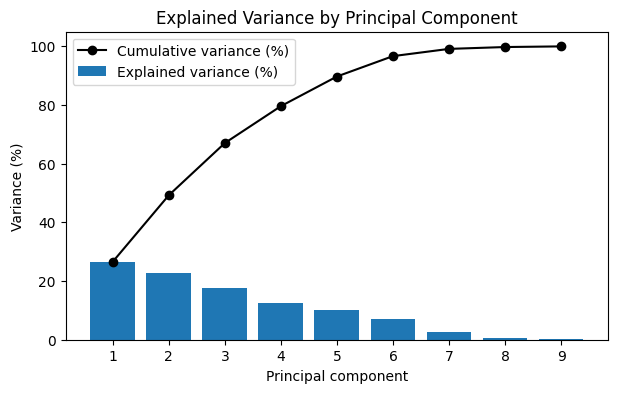

In [9]:
for k in range(len(explained_variance_ratio)):
    print(f"PC{k+1}: eigenvalue = {sorted_eigenvalues[k]:.4f} | "
          f"explained = {explained_variance_ratio[k]*100:5.2f}% | "
          f"cumulative = {cumulative_variance[k]*100:6.2f}%")

import matplotlib.pyplot as plt
pcs = np.arange(1, len(explained_variance_ratio) + 1)
plt.figure(figsize=(7, 4))
plt.bar(pcs, explained_variance_ratio * 100, label="Explained variance (%)")
plt.plot(pcs, cumulative_variance * 100, color="black", marker="o", label="Cumulative variance (%)")
plt.xlabel("Principal component")
plt.ylabel("Variance (%)")
plt.title("Explained Variance by Principal Component")
plt.xticks(pcs)
plt.legend()
plt.show()

In [ ]:
# Dynamic selection: smallest k whose cumulative variance reaches the target
target = 0.85
k_dynamic = int(np.argmax(cumulative_variance >= target) + 1)
print(f"Components needed for {target*100:.0f}% variance: {k_dynamic}")
print(f"Variance kept with k={k_dynamic}: {cumulative_variance[k_dynamic-1]*100:.2f}%")
print(f"Variance kept with k=2: {cumulative_variance[1]*100:.2f}%")

Components needed for 85% variance: 5
Variance kept with k=5: 89.73%
Variance kept with k=2: 49.24%


### Step 6: Project Data onto Principal Components
Now that we’ve selected the number of components, we will project the original data onto the chosen principal components.
Fill in the code to perform the projection.

In [10]:
# Step 6: Project Data onto Principal Components
num_components = 2  # chosen based on cumulative_variance above
reduced_data = standardized_data @ sorted_eigenvectors[:, :num_components]
reduced_data[:5]

array([[ 0.24940801, -0.87807521],
       [ 3.02840282,  0.16537683],
       [-1.4461163 , -0.52077194],
       [ 0.8389454 ,  0.21011005],
       [-1.29797787, -0.03357329]])

### Step 7: Output the Reduced Data
Finally, display the reduced data obtained by projecting the original dataset onto the selected principal components.

In [11]:
# Step 7: Output the Reduced Data
print(f'Reduced Data Shape: {reduced_data.shape}')
reduced_data[:5]

Reduced Data Shape: (60, 2)


array([[ 0.24940801, -0.87807521],
       [ 3.02840282,  0.16537683],
       [-1.4461163 , -0.52077194],
       [ 0.8389454 ,  0.21011005],
       [-1.29797787, -0.03357329]])

### Step 8: Visualize Before and After PCA
Now, let's plot the original data and the data after PCA to compare the reduction in dimensions visually.

Number of points before: 60 | after: 60
Variance of PC1: 2.432 | Variance of PC2: 2.075


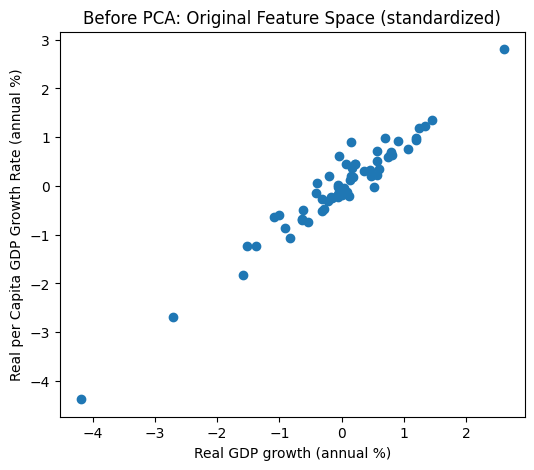

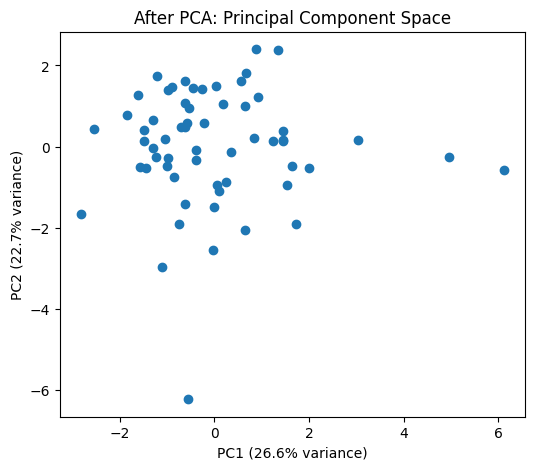

In [12]:
# Step 8: Visualize Before and After PCA
import matplotlib.pyplot as plt

# Plot original data (first two features for simplicity)
plt.figure(figsize=(6, 5))
plt.scatter(standardized_data[:, 0], standardized_data[:, 1])
plt.xlabel(wanted_indicators[0])
plt.ylabel(wanted_indicators[1])
plt.title("Before PCA: Original Feature Space (standardized)")
plt.show()

# Plot reduced data after PCA
plt.figure(figsize=(6, 5))
plt.scatter(reduced_data[:, 0], reduced_data[:, 1])
plt.xlabel(f"PC1 ({explained_variance_ratio[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({explained_variance_ratio[1]*100:.1f}% variance)")
plt.title("After PCA: Principal Component Space")
plt.show()

print("Number of points before:", standardized_data.shape[0], "| after:", reduced_data.shape[0])
print("Variance of PC1:", round(float(np.var(reduced_data[:, 0], ddof=1)), 3),
      "| Variance of PC2:", round(float(np.var(reduced_data[:, 1], ddof=1)), 3))

Please make sure you do not use more than 5 lines to answer each of the following points:

1. Interpret the Visual you just created of the before and after PCA
2. Explain why you selected the number of principle components, more especially explain what tradeoffs you are making
3. Clearly mention based on your use case/ dataset ("economic activity”, “population pressure”), What information is lost when reducing dimensions?


**1. Interpret the before and after PCA visual**

> *Before PCA, the plot shows only two of the nine indicators (GDP growth vs per-capita growth). The 60 countries form a tight diagonal band because the two move almost together (covariance about 0.98). After PCA, the same 60 countries are centered at (0, 0), and the axes are new combinations of all nine indicators, not one original feature. The spread is wider along PC1 (variance 2.43) than PC2 (2.08), as expected, and no countries were lost. The plot is now less redundant, but it only shows about 49% of the total variance.*

**2. Why this number of principal components, and what trade-offs?**

> *We kept 2 components because they let us plot the data in 2D and they reduce 9 indicators to 2. The trade-off is that they keep only 49.2% of the variance, so over half the information is dropped. The scree plot shows no sharp elbow, since variance is spread across many components. Reaching 85% would need 5 components (89.7%), which is more accurate but harder to visualize. So I traded accuracy for simplicity.*

**3. What information is lost when reducing dimensions (economic activity, population pressure)?**

> *The dropped components still carry about 51% of the variance, including structure such as household consumption vs capital formation (mostly PC3). Economic activity is partly lost because each country's specific trade, investment and fiscal profile is averaged into two axes. Population pressure is lost more subtly: our dataset has no population column, but the gap between GDP growth and per-capita growth reflects population growth, and that gap sits in the smallest components (PC9, 0.2%). Dropping those components erases it.*